# Gaussian Process Forecasting & Anomaly Detection
### Applied to Station Inspection Times

---

## 1. What is a Gaussian Process?

A **Gaussian Process (GP)** is a probability distribution over *functions*. Instead of fitting a single curve, a GP fits a whole *family* of plausible curves and tells you how confident it is everywhere.

### Core Analogy
> "A GP is to functions what a Gaussian distribution is to numbers."

A normal Gaussian describes a single number with mean μ and variance σ².  
A GP describes a distribution over an entire **function** with a **mean function** m(x) and a **kernel (covariance) function** k(x, x').

Any finite set of function values is jointly Gaussian:  
**f ~ N(m, K)** where K_ij = k(x_i, x_j) — the kernel matrix.

### The Rubber Band Analogy
- Points **close together** → band is taut → predictions tightly correlated  
- Points **far apart** → band is slack → predictions grow uncertain  
The **kernel** controls how this tension decays with distance.

### GP Regression

Given training data (X, y) with noise ε ~ N(0, σ_n²), the posterior at test points X_* is:

**Posterior mean** (prediction):  
f̄ = K_{*X} (K_{XX} + σ_n² I)⁻¹ y

**Posterior variance** (uncertainty):  
cov(f_*) = K_{**} - K_{*X} (K_{XX} + σ_n² I)⁻¹ K_{X*}

**Key insight**: Variance shrinks near data points and grows in gaps — automatically, for free.

### Kernels

| Kernel | Behaviour | Use when... |
|---|---|---|
| **RBF** | Very smooth | Stable, smooth processes |
| **Matern 3/2** | Rough, 1x differentiable | Real-world data with jumps |
| **Matern 5/2** | Between RBF and Matern 3/2 | Good default |
| **Periodic + RBF** | Repeating + smooth trend | Weekly seasonality |
| **RationalQuadratic** | Multi-scale smoothness | Mix of length scales |

Kernels can be **combined**: k1 + k2 (additive) or k1 * k2 (multiplicative).

### GP Anomaly Detection

Once fit, every point is scored: z = (y - f̄) / sqrt(var(f))  
Points with |z| > threshold are anomalies — outside what the model expected. Unlike a simple threshold, GP detection *adapts* to local trends and uncertainty.


---
## 2. Setup & Imports


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, WhiteKernel, ConstantKernel as C,
    ExpSineSquared, RationalQuadratic
)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11
print('All imports OK')


All imports OK


---
## 3. Configuration — Edit Here

All tunable parameters live in this one cell — including the **metric name**. Change `METRIC` to any numeric column in your CSV, then re-run all cells below.


In [47]:
# ========================================================
#   METRIC — change this to any numeric column name
# ========================================================
METRIC = 'ced_station__upstream_waiting_time'

# ========================================================
#          MAIN CONFIGURATION — EDIT HERE
# ========================================================

# 1. DATE RANGE (None = use all data)
DATE_START = None   # 'YYYY-MM-DD' or None
DATE_END   = None   # 'YYYY-MM-DD' or None

# 2. AGGREGATION:  'mean' | 'median' | 'p95' | 'p99'
AGGREGATE = 'mean'

# 3. OUTLIER REMOVAL: drop raw rows above this value before aggregating (None = keep all)
OUTLIER_CUTOFF = 15.0   # seconds

# 4. KERNEL:  'rbf' | 'matern32' | 'matern52' | 'periodic_rbf' | 'rq'
KERNEL_CHOICE = 'matern52'

# 5. FORECAST: how many days ahead to predict
FORECAST_DAYS = 3

# 6. CONFIDENCE INTERVAL coverage (0.95 = 95%)
CI_COVERAGE = 0.95

# 7. ANOMALY threshold: flag if |z-score| > this
ANOMALY_Z_THRESHOLD = 2.0

# 8. NORMALISE y before fitting?
NORMALISE_Y = True

# 9. Optimiser restarts (more = better but slower)
N_RESTARTS = 5

# ── Derived ──────────────────────────────────────────
CI_Z = stats.norm.ppf(0.5 + CI_COVERAGE / 2)

print(f"Config loaded:")
print(f"  Metric     : {METRIC}")
print(f"  Date range : {DATE_START} to {DATE_END}")
print(f"  Aggregate  : {AGGREGATE}")
print(f"  Kernel     : {KERNEL_CHOICE}")
print(f"  Forecast   : {FORECAST_DAYS} days")
print(f"  CI         : {CI_COVERAGE*100:.0f}% ({CI_Z:.2f} sigma)")
print(f"  Anomaly z  : |z| > {ANOMALY_Z_THRESHOLD}")


Config loaded:
  Metric     : ced_station__upstream_waiting_time
  Date range : None to None
  Aggregate  : mean
  Kernel     : matern52
  Forecast   : 3 days
  CI         : 95% (1.96 sigma)
  Anomaly z  : |z| > 2.0


---
## 4. Load & Explore Data


In [48]:
df_raw = pd.read_csv('/home/dhruvkumarjiguda/code/arima/datasets/training_data.csv')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], utc=True)
df_raw['date'] = pd.to_datetime(df_raw['timestamp'].dt.date)


print(f"Records: {len(df_raw):,}")
print(f"Date range: {df_raw['date'].min().date()} to {df_raw['date'].max().date()}")
print(f"Unique dates: {df_raw['date'].nunique()}")
print(f"\n{METRIC} summary:")
print(df_raw[METRIC].describe().round(3))


Records: 670
Date range: 2026-03-03 to 2026-03-09
Unique dates: 6

ced_station__upstream_waiting_time summary:
count     670.000
mean       43.506
std       154.418
min         0.015
25%         0.016
50%         0.031
75%        75.076
max      2981.473
Name: ced_station__upstream_waiting_time, dtype: float64


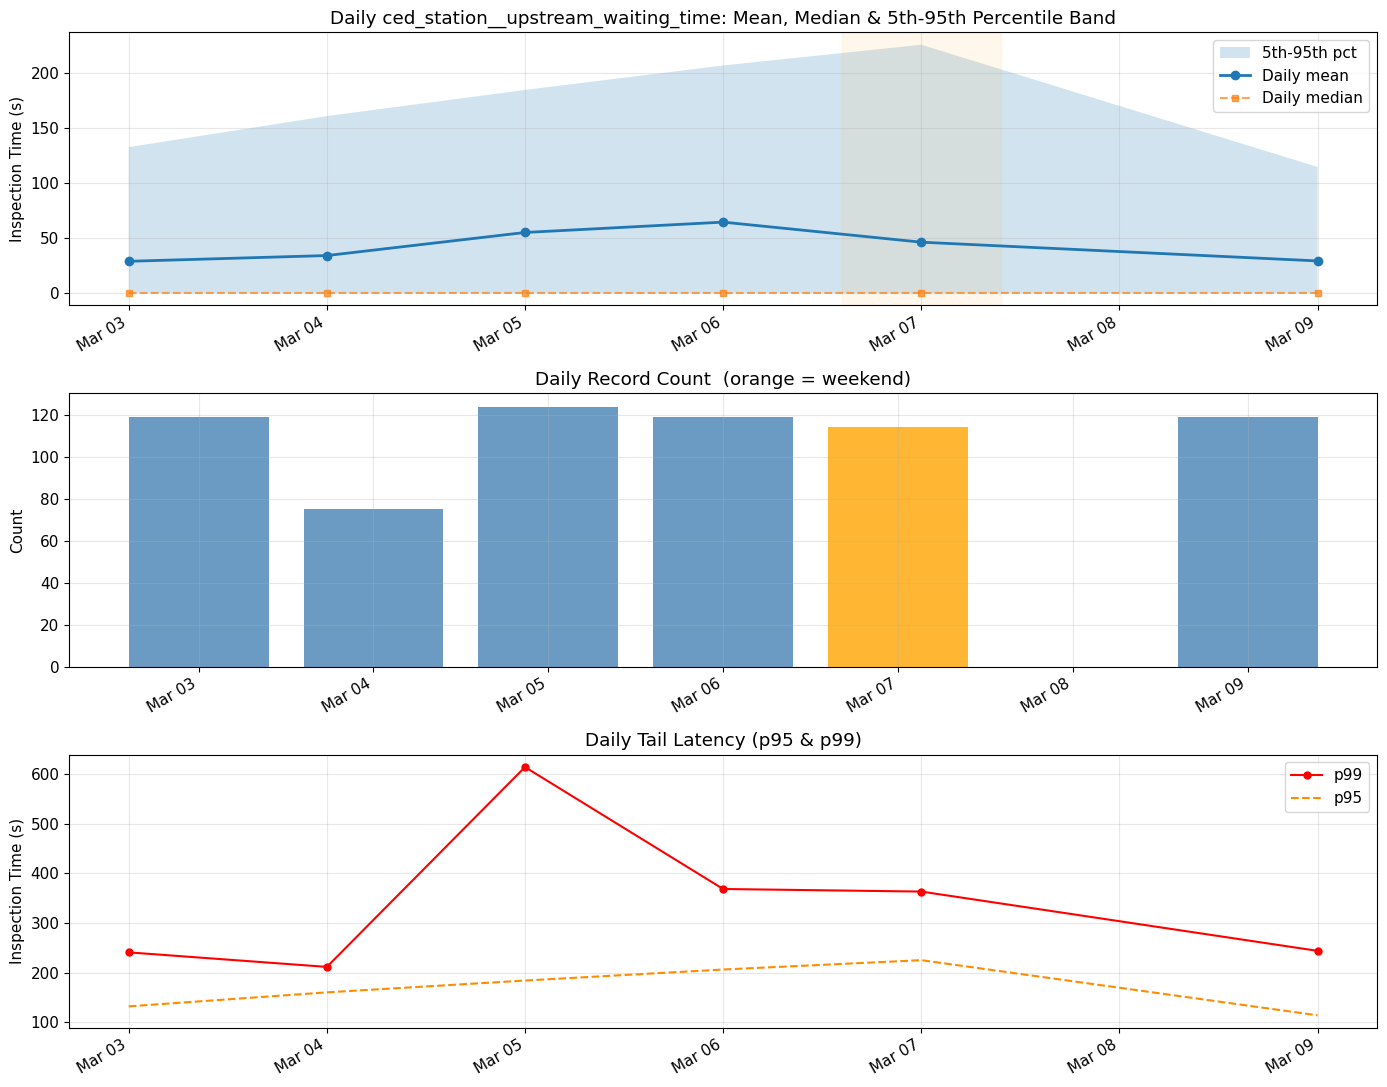

In [49]:
daily = df_raw.groupby('date')[METRIC].agg(
    count='count', mean='mean', median='median', std='std',
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99)
).reset_index()
daily['dow'] = daily['date'].dt.day_name()
daily['is_weekend'] = daily['date'].dt.dayofweek >= 5

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

ax = axes[0]
ax.fill_between(daily['date'], daily['p5'], daily['p95'], alpha=0.2, label='5th-95th pct')
ax.plot(daily['date'], daily['mean'], 'o-', lw=2, label='Daily mean', ms=6)
ax.plot(daily['date'], daily['median'], 's--', lw=1.5, label='Daily median', ms=5, alpha=0.7)
for _, row in daily[daily['is_weekend']].iterrows():
    ax.axvspan(row['date'] - pd.Timedelta('0.4d'), row['date'] + pd.Timedelta('0.4d'),
               alpha=0.08, color='orange')
ax.set_title(f'Daily {METRIC}: Mean, Median & 5th-95th Percentile Band')
ax.set_ylabel('Inspection Time (s)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax = axes[1]
ax.bar(daily['date'], daily['count'],
       color=['orange' if w else 'steelblue' for w in daily['is_weekend']],
       alpha=0.8, width=0.8)
ax.set_title('Daily Record Count  (orange = weekend)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax = axes[2]
ax.plot(daily['date'], daily['p99'], 'r-o', ms=5, label='p99')
ax.plot(daily['date'], daily['p95'], 'darkorange', ls='--', lw=1.5, label='p95')
ax.set_title('Daily Tail Latency (p95 & p99)')
ax.set_ylabel('Inspection Time (s)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

for ax in axes:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## 5. Prepare Data


In [50]:
# Filter dates
df = df_raw.copy()
if DATE_START:
    df = df[df['date'] >= DATE_START]
if DATE_END:
    df = df[df['date'] <= DATE_END]

# Remove outliers
if OUTLIER_CUTOFF:
    n_before = len(df)
    df = df[df[METRIC] <= OUTLIER_CUTOFF]
    print(f"Outlier removal: dropped {n_before - len(df):,} rows > {OUTLIER_CUTOFF}s")

# Aggregate per day
agg_funcs = {
    'mean':   lambda x: x.mean(),
    'median': lambda x: x.median(),
    'p95':    lambda x: x.quantile(0.95),
    'p99':    lambda x: x.quantile(0.99),
}
series = df.groupby('date')[METRIC].apply(agg_funcs[AGGREGATE]).reset_index()
series.columns = ['date', 'y']
series = series.sort_values('date').reset_index(drop=True)

# Numeric X = days since first date
t0 = series['date'].min()
series['x'] = (series['date'] - t0).dt.days.astype(float)

X_train = series['x'].values.reshape(-1, 1)
y_train = series['y'].values

print(f"Training points : {len(X_train)}")
print(f"x range         : {X_train.min():.0f} to {X_train.max():.0f} days")
print(f"y ({AGGREGATE}) : {y_train.min():.3f} to {y_train.max():.3f} s")


Outlier removal: dropped 217 rows > 15.0s
Training points : 6
x range         : 0 to 6 days
y (mean) : 0.369 to 0.722 s


---
## 5b. Train / Test Split

We hold out the **last N days** as a test set — the GP is fit only on training data,
then evaluated on unseen future points. This is a strict **temporal split**: no shuffling,
no leakage.

```
|--- train (days 1 to N-TEST_DAYS) ---||--- test (last TEST_DAYS days) ---|
         GP fits here                          evaluate here
```


In [51]:
# =====================================================
#   TRAIN / TEST SPLIT — EDIT THIS
# =====================================================
TEST_DAYS = 2   # hold out the last N days as the test set
#   Set to 0 to disable the split and use all data for fitting
# =====================================================

if TEST_DAYS > 0:
    cutoff = series['date'].max() - pd.Timedelta(days=TEST_DAYS - 1)
    train  = series[series['date'] <  cutoff].reset_index(drop=True)
    test   = series[series['date'] >= cutoff].reset_index(drop=True)
else:
    train  = series.copy()
    test   = pd.DataFrame(columns=series.columns)

X_train = train['x'].values.reshape(-1, 1)
y_train = train['y'].values
X_test  = test['x'].values.reshape(-1, 1) if len(test) else np.array([]).reshape(0,1)
y_test  = test['y'].values                if len(test) else np.array([])

# Normalise using ONLY training stats — no data leakage into test set
if NORMALISE_Y:
    y_mean   = y_train.mean()
    y_std    = y_train.std()
    y_scaled = (y_train - y_mean) / y_std
else:
    y_mean, y_std = 0.0, 1.0
    y_scaled = y_train

print(f"Train : {len(train)} days  ({train['date'].min().date()} to {train['date'].max().date()})")
if len(test):
    print(f"Test  : {len(test)} days  ({test['date'].min().date()} to {test['date'].max().date()})")
else:
    print("Test  : disabled (TEST_DAYS = 0)")


Train : 5 days  (2026-03-03 to 2026-03-07)
Test  : 1 days  (2026-03-09 to 2026-03-09)


---
## 6. Define & Fit the Gaussian Process


In [52]:
def build_kernel(choice):
    WK = WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1.0))
    if choice == 'rbf':
        k = C(1.0, (0.1, 10)) * RBF(length_scale=2, length_scale_bounds=(0.5, 20))
    elif choice == 'matern32':
        k = C(1.0, (0.1, 10)) * Matern(length_scale=2, length_scale_bounds=(0.5, 20), nu=1.5)
    elif choice == 'matern52':
        k = C(1.0, (0.1, 10)) * Matern(length_scale=2, length_scale_bounds=(0.5, 20), nu=2.5)
    elif choice == 'periodic_rbf':
        seasonal = C(0.5, (0.01, 5)) * ExpSineSquared(
            length_scale=1.0, periodicity=7.0,
            length_scale_bounds=(0.5, 5),
            periodicity_bounds=(6.5, 7.5))
        trend = C(1.0, (0.1, 10)) * RBF(length_scale=5, length_scale_bounds=(2, 30))
        k = seasonal + trend
    elif choice == 'rq':
        k = C(1.0, (0.1, 10)) * RationalQuadratic(length_scale=2, alpha=0.5,
                                                    length_scale_bounds=(0.5, 20))
    else:
        raise ValueError(f"Unknown kernel: {choice}")
    return k + WK

gp = GaussianProcessRegressor(
    kernel=build_kernel(KERNEL_CHOICE),
    n_restarts_optimizer=N_RESTARTS,
    normalize_y=False,
    random_state=42
)
print(f"Fitting GP with kernel: {KERNEL_CHOICE} ...")
gp.fit(X_train, y_scaled)
print(f"Optimised kernel:\n  {gp.kernel_}")
print(f"\nLog-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}")


Fitting GP with kernel: matern52 ...
Optimised kernel:
  1.08**2 * Matern(length_scale=0.9, nu=2.5) + WhiteKernel(noise_level=0.001)

Log-marginal-likelihood: -6.988


---
## 7. Forecast


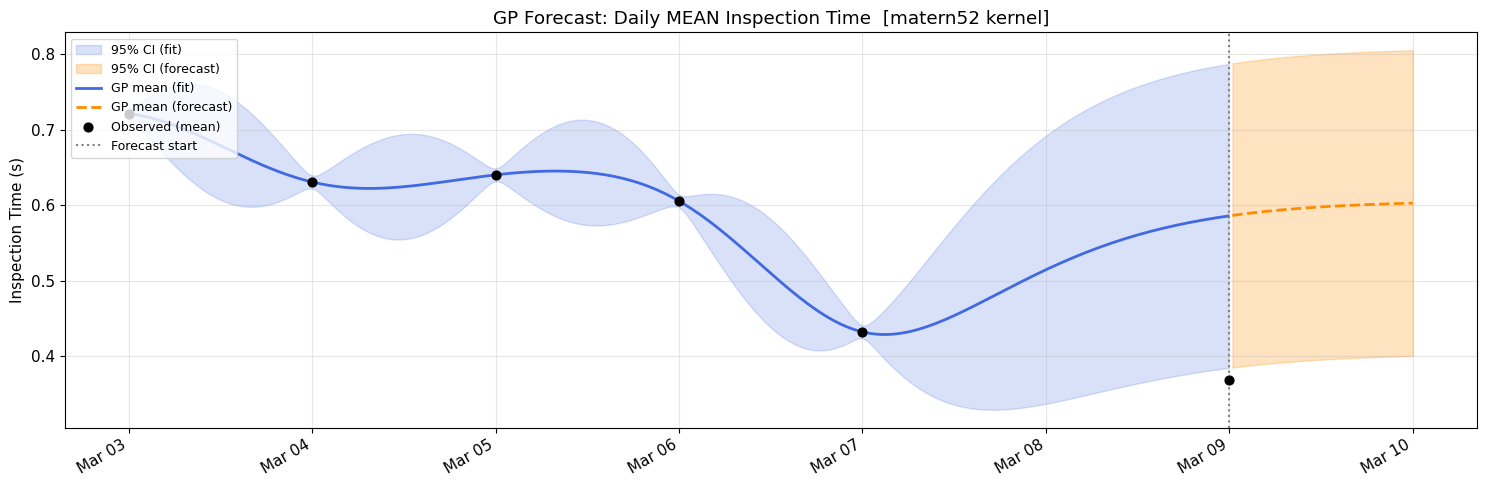

In [53]:
# Build prediction grid
x_max  = X_train.max()
x_pred = np.linspace(0, x_max + FORECAST_DAYS, 300).reshape(-1, 1)
dates_pred = pd.to_datetime([t0 + pd.Timedelta(days=float(x)) for x in x_pred.ravel()])

# Posterior mean and std
mu_scaled, sigma_scaled = gp.predict(x_pred, return_std=True)
mu    = mu_scaled    * y_std + y_mean
sigma = sigma_scaled * y_std
ci_lo = mu - CI_Z * sigma
ci_hi = mu + CI_Z * sigma

last_observed = series['date'].max()
is_future = dates_pred > last_observed

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(dates_pred[~is_future], ci_lo[~is_future], ci_hi[~is_future],
                alpha=0.2, color='royalblue', label=f'{CI_COVERAGE*100:.0f}% CI (fit)')
ax.fill_between(dates_pred[is_future], ci_lo[is_future], ci_hi[is_future],
                alpha=0.25, color='darkorange', label=f'{CI_COVERAGE*100:.0f}% CI (forecast)')
ax.plot(dates_pred[~is_future], mu[~is_future], '-', color='royalblue', lw=2, label='GP mean (fit)')
ax.plot(dates_pred[is_future],  mu[is_future],  '--', color='darkorange', lw=2, label='GP mean (forecast)')
ax.scatter(series['date'], series['y'], color='black', s=40, zorder=5, label=f'Observed ({AGGREGATE})')
ax.axvline(last_observed, color='grey', ls=':', lw=1.5, label='Forecast start')
ax.set_title(f'GP Forecast: Daily {AGGREGATE.upper()} Inspection Time  [{KERNEL_CHOICE} kernel]')
ax.set_ylabel('Inspection Time (s)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## 8. Anomaly Detection


In [54]:
# Z-score each training point against the GP posterior
mu_obs_s, sig_obs_s = gp.predict(X_train, return_std=True)
mu_obs  = mu_obs_s  * y_std + y_mean
sig_obs = sig_obs_s * y_std

train['mu_gp']    = mu_obs
train['sigma_gp'] = sig_obs
train['residual'] = y_train - mu_obs
train['z_score']  = train['residual'] / (sig_obs + 1e-9)
train['anomaly']  = train['z_score'].abs() > ANOMALY_Z_THRESHOLD
train['dow']      = train['date'].dt.day_name()

anomalies = train[train['anomaly']]
print(f"Anomalies in training window (|z| > {ANOMALY_Z_THRESHOLD}): {len(anomalies)}")
if len(anomalies):
    print(anomalies[['date','dow','y','mu_gp','residual','z_score']].to_string(index=False))


Anomalies in training window (|z| > 2.0): 0


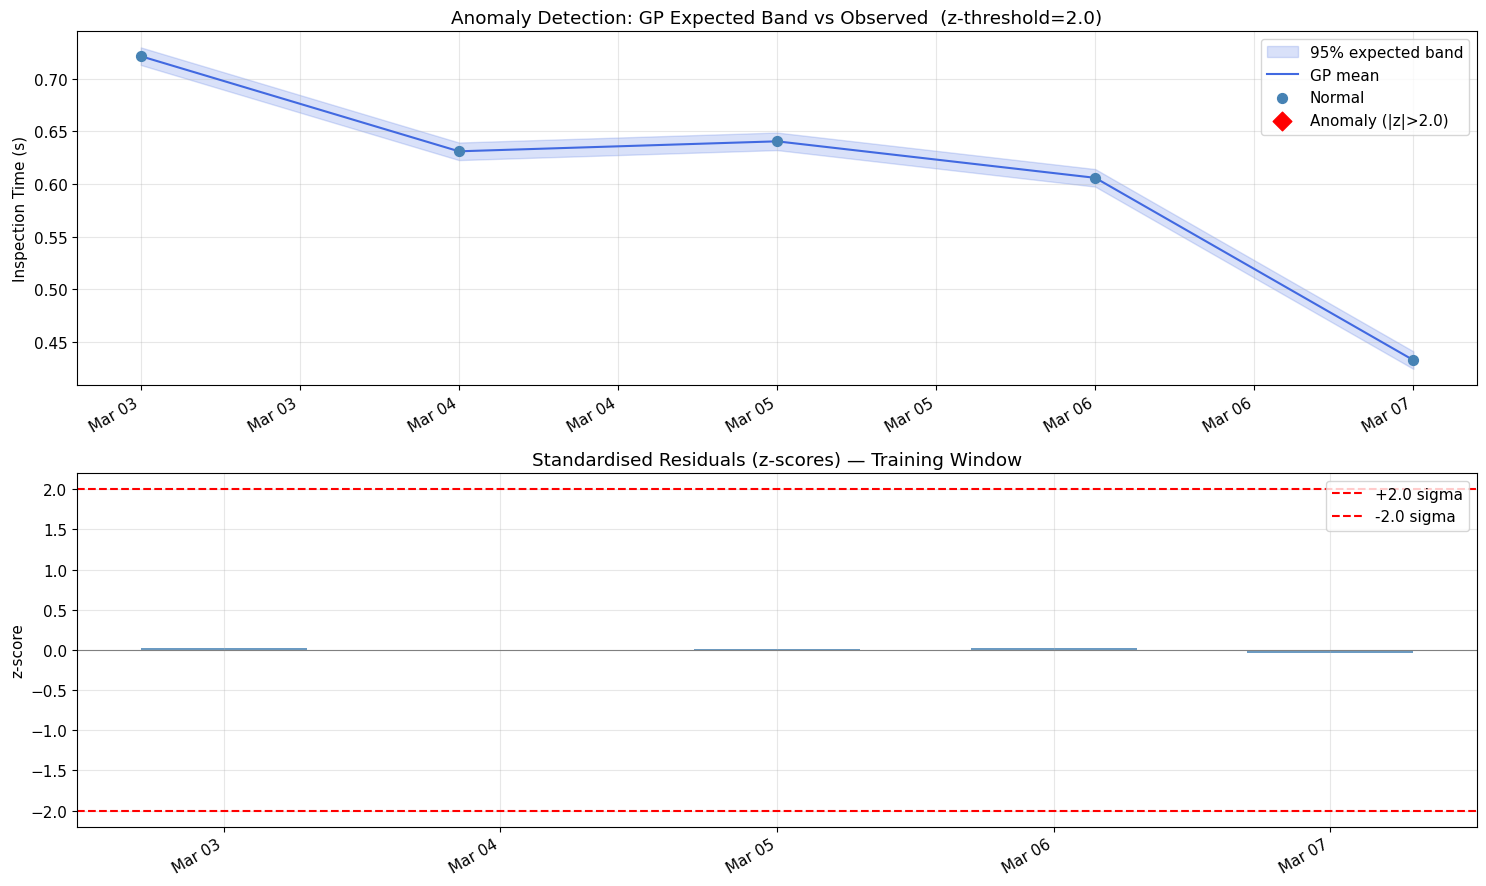

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

ci_lo_obs = mu_obs - CI_Z * sig_obs
ci_hi_obs = mu_obs + CI_Z * sig_obs

ax = axes[0]
ax.fill_between(train['date'], ci_lo_obs, ci_hi_obs,
                alpha=0.2, color='royalblue', label=f'{CI_COVERAGE*100:.0f}% expected band')
ax.plot(train['date'], mu_obs, '-', color='royalblue', lw=1.5, label='GP mean')
normal = train[~train['anomaly']]
ax.scatter(normal['date'],    normal['y'],    color='steelblue', s=50, zorder=4, label='Normal')
ax.scatter(anomalies['date'], anomalies['y'], color='red', s=90, zorder=5,
           marker='D', label=f'Anomaly (|z|>{ANOMALY_Z_THRESHOLD})')
for _, row in anomalies.iterrows():
    ax.annotate(f"{row['date'].strftime('%b %d')} z={row['z_score']:.1f}",
                xy=(row['date'], row['y']),
                xytext=(5, 8), textcoords='offset points',
                fontsize=8, color='red', fontweight='bold')
ax.set_title(f'Anomaly Detection: GP Expected Band vs Observed  (z-threshold={ANOMALY_Z_THRESHOLD})')
ax.set_ylabel('Inspection Time (s)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax2 = axes[1]
colors = ['red' if a else 'steelblue' for a in train['anomaly']]
ax2.bar(train['date'], train['z_score'], color=colors, alpha=0.8, width=0.6)
ax2.axhline( ANOMALY_Z_THRESHOLD, color='red', ls='--', lw=1.5, label=f'+{ANOMALY_Z_THRESHOLD} sigma')
ax2.axhline(-ANOMALY_Z_THRESHOLD, color='red', ls='--', lw=1.5, label=f'-{ANOMALY_Z_THRESHOLD} sigma')
ax2.axhline(0, color='grey', lw=0.8)
ax2.set_title('Standardised Residuals (z-scores) — Training Window')
ax2.set_ylabel('z-score')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## 9. Kernel Comparison
Compare all kernels side-by-side. Higher log-ML = better fit.


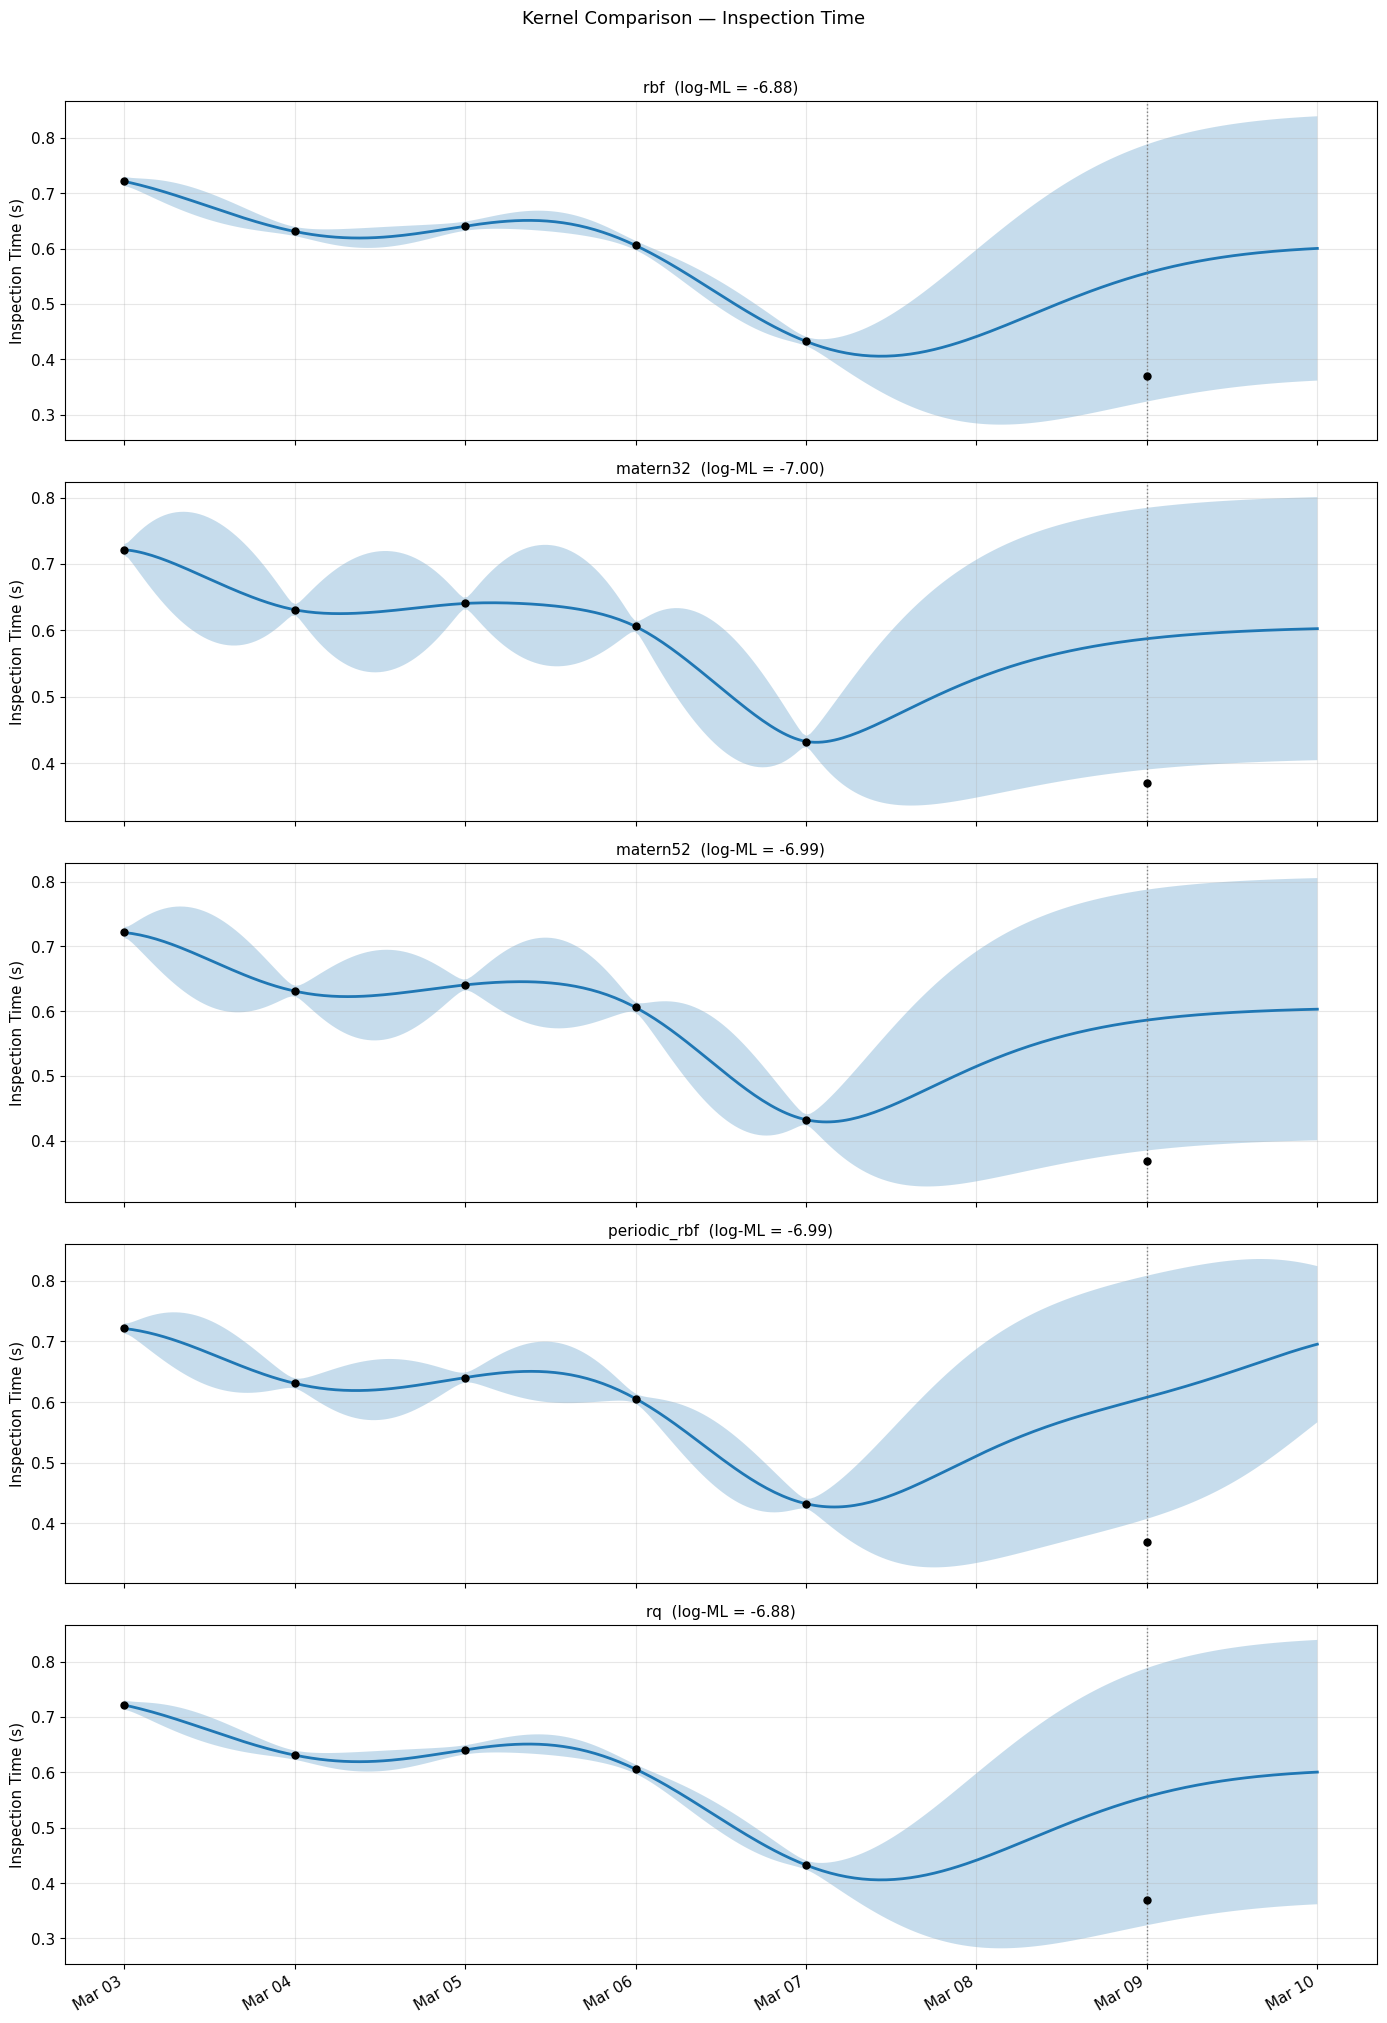

In [56]:
kernels_to_compare = ['rbf', 'matern32', 'matern52', 'periodic_rbf', 'rq']
fig, axes = plt.subplots(len(kernels_to_compare), 1,
                          figsize=(14, 4 * len(kernels_to_compare)), sharex=True)

for ax, kname in zip(axes, kernels_to_compare):
    _gp = GaussianProcessRegressor(kernel=build_kernel(kname), n_restarts_optimizer=3, random_state=42)
    _gp.fit(X_train, y_scaled)
    _mu_s, _sig_s = _gp.predict(x_pred, return_std=True)
    _mu  = _mu_s  * y_std + y_mean
    _sig = _sig_s * y_std
    _lml = _gp.log_marginal_likelihood_value_
    ax.fill_between(dates_pred, _mu - CI_Z*_sig, _mu + CI_Z*_sig, alpha=0.25)
    ax.plot(dates_pred, _mu, lw=2)
    ax.scatter(series['date'], series['y'], color='black', s=25, zorder=5)
    ax.axvline(last_observed, color='grey', ls=':', lw=1)
    ax.set_title(f'{kname}  (log-ML = {_lml:.2f})', fontsize=11)
    ax.set_ylabel('Inspection Time (s)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.suptitle('Kernel Comparison — Inspection Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


---
## 10. Test Set Evaluation

Evaluate the fitted GP against the held-out test days.  
Three things to check:
- **MAE / RMSE** — average point prediction error
- **CI coverage** — what % of test points actually fell inside the confidence band (should be close to CI_COVERAGE)
- **Visual** — do the test points sit reasonably within the forecast band?

> **Coverage is the most important metric for GPs.** If you set 95% CI but only 60% of test points fall inside it, the GP is overconfident about its uncertainty.


In [57]:
if len(test) == 0:
    print("No test set — set TEST_DAYS > 0 in Section 5b to enable evaluation.")
else:
    mu_test_s, sig_test_s = gp.predict(X_test, return_std=True)
    mu_test  = mu_test_s  * y_std + y_mean
    sig_test = sig_test_s * y_std

    ci_lo_test = mu_test - CI_Z * sig_test
    ci_hi_test = mu_test + CI_Z * sig_test

    mae      = np.mean(np.abs(y_test - mu_test))
    rmse     = np.sqrt(np.mean((y_test - mu_test)**2))
    coverage = np.mean((y_test >= ci_lo_test) & (y_test <= ci_hi_test))

    print(f"Test set results ({len(test)} days)")
    print(f"  MAE            : {mae:.4f} s")
    print(f"  RMSE           : {rmse:.4f} s")
    print(f"  CI coverage    : {coverage*100:.1f}%  (target: {CI_COVERAGE*100:.0f}%)")

    if coverage >= CI_COVERAGE - 0.05:
        print("  Calibration    : GOOD — coverage near target")
    elif coverage >= CI_COVERAGE - 0.15:
        print("  Calibration    : OK — slightly overconfident, consider wider CI or more restarts")
    else:
        print("  Calibration    : POOR — GP is overconfident; try a different kernel or increase N_RESTARTS")

    result_df = test[['date','y']].copy()
    result_df['gp_mean']  = mu_test
    result_df['gp_std']   = sig_test
    result_df['ci_lo']    = ci_lo_test
    result_df['ci_hi']    = ci_hi_test
    result_df['error']    = y_test - mu_test
    result_df['in_ci']    = (y_test >= ci_lo_test) & (y_test <= ci_hi_test)
    result_df['z_score']  = result_df['error'] / (sig_test + 1e-9)
    print(f"\nPer-day breakdown:")
    print(result_df.round(4).to_string(index=False))


Test set results (1 days)
  MAE            : 0.2167 s
  RMSE           : 0.2167 s
  CI coverage    : 0.0%  (target: 95%)
  Calibration    : POOR — GP is overconfident; try a different kernel or increase N_RESTARTS

Per-day breakdown:
      date      y  gp_mean  gp_std  ci_lo  ci_hi   error  in_ci  z_score
2026-03-09 0.3695   0.5862  0.1027 0.3849 0.7875 -0.2167  False  -2.1103


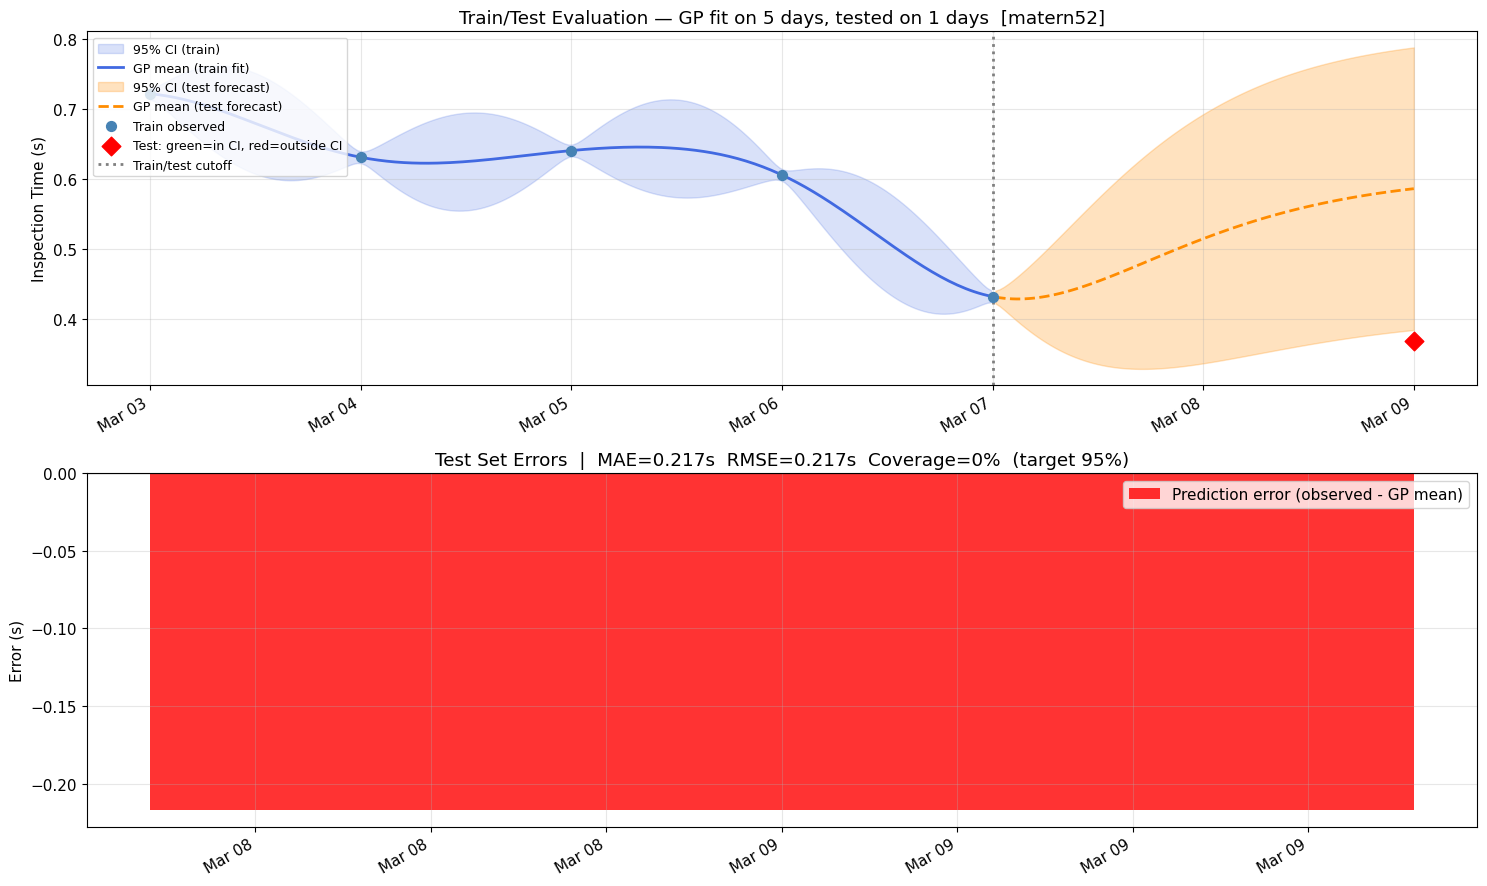

In [58]:
if len(test) == 0:
    print("No test set — set TEST_DAYS > 0 in Section 5b.")
else:
    x_full  = np.linspace(0, series['x'].max(), 300).reshape(-1, 1)
    dates_full = pd.to_datetime([t0 + pd.Timedelta(days=float(x)) for x in x_full.ravel()])

    mu_full_s, sig_full_s = gp.predict(x_full, return_std=True)
    mu_full  = mu_full_s  * y_std + y_mean
    sig_full = sig_full_s * y_std

    train_cutoff = train['date'].max()
    is_test_range = dates_full > train_cutoff

    fig, axes = plt.subplots(2, 1, figsize=(15, 9))

    ax = axes[0]
    ax.fill_between(dates_full[~is_test_range],
                    mu_full[~is_test_range] - CI_Z*sig_full[~is_test_range],
                    mu_full[~is_test_range] + CI_Z*sig_full[~is_test_range],
                    alpha=0.2, color='royalblue', label=f'{CI_COVERAGE*100:.0f}% CI (train)')
    ax.plot(dates_full[~is_test_range], mu_full[~is_test_range],
            '-', color='royalblue', lw=2, label='GP mean (train fit)')
    ax.fill_between(dates_full[is_test_range],
                    mu_full[is_test_range] - CI_Z*sig_full[is_test_range],
                    mu_full[is_test_range] + CI_Z*sig_full[is_test_range],
                    alpha=0.25, color='darkorange', label=f'{CI_COVERAGE*100:.0f}% CI (test forecast)')
    ax.plot(dates_full[is_test_range], mu_full[is_test_range],
            '--', color='darkorange', lw=2, label='GP mean (test forecast)')
    ax.scatter(train['date'], train['y'], color='steelblue', s=50, zorder=5, label='Train observed')
    ax.scatter(test['date'],  test['y'],
               color=[('limegreen' if b else 'red') for b in result_df['in_ci']],
               s=90, zorder=6, marker='D',
               label='Test: green=in CI, red=outside CI')
    ax.axvline(train_cutoff, color='grey', ls=':', lw=2, label='Train/test cutoff')
    ax.set_title(f'Train/Test Evaluation — GP fit on {len(train)} days, tested on {len(test)} days  [{KERNEL_CHOICE}]')
    ax.set_ylabel('Inspection Time (s)')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    ax2 = axes[1]
    bar_colors = ['limegreen' if b else 'red' for b in result_df['in_ci']]
    ax2.bar(test['date'], result_df['error'], color=bar_colors, alpha=0.8, width=0.6,
            label='Prediction error (observed - GP mean)')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_title(f'Test Set Errors  |  MAE={mae:.3f}s  RMSE={rmse:.3f}s  Coverage={coverage*100:.0f}%  (target {CI_COVERAGE*100:.0f}%)')
    ax2.set_ylabel('Error (s)')
    ax2.legend()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()


---
## 11. Tuning Guide

| What you want | What to change |
|---|---|
| Change metric | `METRIC` = any numeric column name from the CSV |
| Different statistic | `AGGREGATE` -> 'mean', 'median', 'p95', 'p99' |
| Smoother / rougher fit | `KERNEL_CHOICE` -> 'rbf' (smooth) or 'matern32' (rough) |
| More / fewer anomaly flags | `ANOMALY_Z_THRESHOLD` up=fewer, down=more |
| Wider / narrower CI band | `CI_COVERAGE` |
| Extend forecast | `FORECAST_DAYS` |
| Better fit (slower) | `N_RESTARTS` up |
| Drop extreme outliers | `OUTLIER_CUTOFF` |

---

### What the EDA shows in this dataset

- **670 records, 6 days** (Mar 3 – Mar 9 2026, Mar 8 missing — likely a Sunday).
- **Metric: `ced_station__inspection_time`** — time taken at the inspection step each pallet cycle.
- **Bulk of values: ~2.0s** with a fat right tail up to 24s; median is very stable at ~2.0s but mean drifts 2.4–2.7s day to day.
- **p95 ranges from ~5.1s to ~7.3s** — Mar 5 shows the highest tail, potential inspection delay event.
- **Mar 3 shows elevated std (1.73s)** vs later days — could reflect a warm-up or shift-start effect.

### Suggested next steps
- Try `AGGREGATE = 'p99'` to monitor worst-case inspection delays
- Try `KERNEL_CHOICE = 'matern32'` for a rougher fit that better follows the day-to-day jumps
- Correlate anomaly days with `ced_station__dispensing_time` to see if slow inspections follow slow dispenses
